<h1 align="center" ><i style="font-size:larger"> Mathematics and Computing </i> <br/> The Final Project</h1><h4 align="center">Due: by 11:59:59 p.m. on Saturday, May 2</h4>

<p>&nbsp;</p>

You can attempt to convince me to allow you to do something else, but unless you do, your final project will be an LLM-produced Assignment 5 style Exploratory Data Analysis that is "transferred" to you the Human as described below:  

The required form of the final project is 
> 1. __Statement of the Problem:__ Given: Describes the purpose of your project and its expected outcomes.
> 2. __Exploratory Data Analysis:__ A function whose execution reveals the results of the EDA and returns a pandas DataFrame suitable for addressing the problem in #1 (imputed, pre-processed, etcetera).  
> 3. __Transfer:__ Execute the function in #2 and then use the dataframe it returns to address #1. 
> 4. __Interpretation:__ Write a short 3-5 paragraph report at the end that explains how the results in #3 might be used to address #1

__Rubric:__ Your solution to the problem has to contain the following elements (1 point each): 
1. Must implement at least the function required in #2 AND AT LEAST ONE ADDITIONAL FUNCTION IN #3 (more functions are permissible).
2. Must include markdown cell explanations __INCLUDING__ mathematics typeset with latex (at least 3)
3. Must directly utilize -- i.e., you, not AI -- the __pandas DataFrame__ produced in #2 and used in #3 ( = evidence of transfer).
4. Must generate at least one image (a plot, or histogram, or similar) in #3 independent of AI-EDA in #2.
5. SUBMIT AS EITHER A JUPYTER NOTEBOOK OR A .py FILE.  In either case, final project should execute without errors and produce all required upon execution.

<p>&nbsp;</p>

__REMARKS:__ 
1. YOU ARE NOT REQUIRED TO SOLVE THE PROBLEM OR ANSWER THE QUESTION (doing so requires more math than required for this course). 
2. In data science, the only acceptable solutions are those that are extensively assessed and tested. Avoid generating unverified candidates which you do not test and assess.  THAT IS, THE FINAL PROJECT IS EXPlORATION ONLY.
3. Submission should include __ONLY__ required items.   DO NOT SUBMIT MASSIVE NOTEBOOKS FOR ME TO PLOW THROUGH.  Such is evidence of failure to transfer from AI-EDA to addressing #1.   

---

__FAQS:__ From past semesters
1. __I don't do any math. What should I use LaTeX for?__  Your short report is based on math such as means, medians, scaling, histograms, etcetera produced in #2 and #3.  Thus, you owe it to your client to define and describe mathematically all the mathematics used by either YOU or THE AI (but I only require 3).
2. __Can you give me the data?__  No. Any LLM should be able to guide you in downloading data from a URL and getting you started

<p>&nbsp;</p>

Put your solution below.  ___IN ADDITION TO THE REQUIREMENTS ABOVE, YOUR PROBLEM SOLVING APPROACH AND QUALITY OF YOUR EXPLANATIONS WILL ALSO BE GRADED.___  

## Statement of the Problem 
We have a dataset containing 30,000 observations of clients. These observations detail their demographic factors, credit limits, historical payment statuses, and bill statement amounts over a 6-month period. We need to do special preprocessing in Education and Marriage due to their undocumented categorical levels.
Can I predict who might default on their credit cards based on their features? Because of the nature of this assignment, I will focus only on education and see if there is a trend between education and defaulting. 


## Exploratory Data Analysis
Use AI to do EDA and put the final function produced in the cell(s) below: 

Execution of the function should produce the EDA results and visualizations and should return the dataframe you will use below.

In [11]:
!pip install xlrd

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def ai_exploratory_data_analysis(filepath):
    """
    Reads the credit card dataset, performs preprocessing to clean undocumented 
    categorical levels, conducts basic EDA, and returns a clean DataFrame.
    """
    # 1. Load the data (skipping the top row which usually contains X1, X2 metadata in this UCI dataset)
    df = pd.read_excel(filepath, header=1)
    
    # Rename the target column to something easier to type
    df.rename(columns={'default payment next month': 'default'}, inplace=True)
    
    # 2. Preprocessing: Handle Undocumented Levels (Vectorized, no loops)
    # Education: Group undocumented levels (0, 5, 6) into level 4 ("Others")
    df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
    
    # Marriage: Group undocumented level (0) into level 3 ("Others")
    df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
    
    # 3. Drop 'ID' as it is a unique identifier with no analytical value
    if 'ID' in df.columns:
        df.drop('ID', axis=1, inplace=True)
        
    # 4. EDA Outputs
    print("--- AI EXPLORATORY DATA ANALYSIS SUMMARY ---")
    print(f"Total Observations: {df.shape[0]}")
    print(f"Total Features: {df.shape[1]}")
    print("\nCleaned Education Level Counts:")
    print(df['EDUCATION'].value_counts().sort_index())
    
    # Return the cleaned dataframe
    return df

## Transfer -- You take over!

If __df__ denotes the dataframe returned in __Exploratory Data Analysis,__ then the next cell contains an additional function written by a human (not an AI) that produces at least one visualization in returning results you use in your short report below. 

In [19]:
def Humunction(cdf):
    edur = cdf.groupby('EDUCATION')['default'].mean()
    edur.plot(kind='bar', color='blue', figsize=(8, 5))
    plt.title('Default Rate by Education Level')
    plt.xlabel('1 = Gradschool, 2 = Undergrad, 3 = High School, 4 = Other')
    plt.ylabel('Probability of defaulting on credit card')
    plt.show()
    #This next part is for marriage
    marr = cdf.groupby('MARRIAGE')['default'].mean()
    plt.figure(figsize=(8, 5))
    marr.plot(kind='bar', color='yellow')
    plt.title('Default Rate by Marital Status')
    plt.xlabel('1 = Married, 2 = Single, 3 = Other')
    plt.ylabel('Probability of defaulting on credit card')
    plt.show()
    return edur, marr
    

--- AI EXPLORATORY DATA ANALYSIS SUMMARY ---
Total Observations: 30000
Total Features: 24

Cleaned Education Level Counts:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


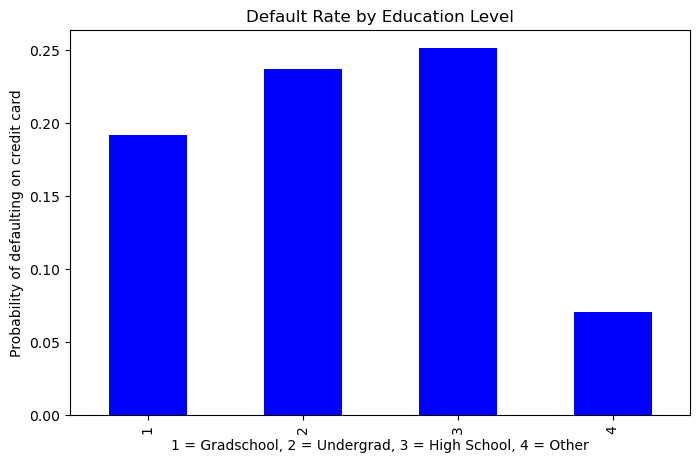

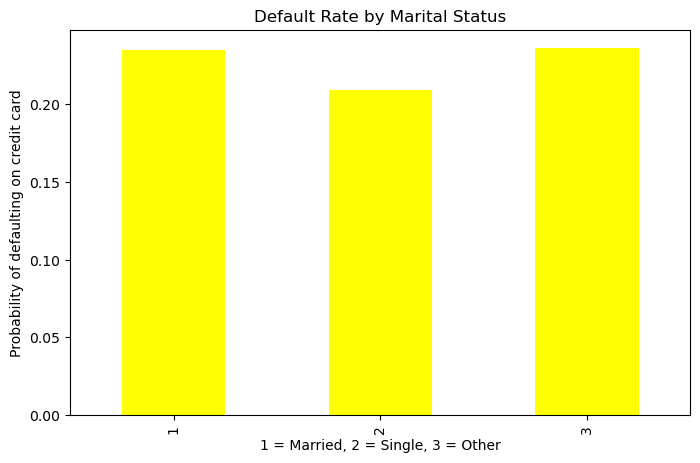

In [20]:
file_name = r"C:\Users\apere_xjtmszd\Downloads\default+of+credit+card+clients (1)\default of credit card clients.xls"

dfc = ai_exploratory_data_analysis(file_name)

edur, marr = Humunction(dfc)

## Short Report (at least 3 to 5 paragraphs)
So, my main goal for this project was to see if there is a trend between defaulting on a credit card and education levels. To do this, in the exploratory data analysis performed by the AI, we first cleaned both marriage and education by putting undocumented levels into an 'other' category. This acts like a piecewise function$$f(E) = \begin{cases} 4, & \text{if } E \in \{0, 5, 6\} \\ E, & \text{otherwise} \end{cases}$$Next, in the human transfer step, I used the cleaned data and isolated the default rates in education and marriatal status. So, we are pretty much calculating the probability of something happening given something else.$$P(\text{Default} \mid \text{Trait} = k) = \frac{P(\text{Default} \cap \text{Trait} = k)}{P(\text{Trait} = k)}$$To do this, I used the pandas vectorization 'groupby' instead of using loops. Because default is binary, ($y_i = 1$ indicates a default and $y_i = 0$ indicates no default) using the mean function calculates the sample proportion. The equation is$$\hat{p} = \frac{1}{n} \sum_{i=1}^{n} y_i$$So, by summing the binary defaults and dividing by the number of people in that specific group gives us the probability of defaulting. Also, it is worthy to note that the y-axis numbers can denoted as a percentage using $p \times 100$. Now, let's look at the barcharts. We can see in the "Default Rate by Education level", High School graduates (Level 3) carry the highest risk of default regarding education. We can also see that the marital status visualization reveals differences risk, with married clients (Level 1) exhibiting a higher probability of default than single clients (Level 2). A bank could take advantage of this by offering better rates to single and more educated individuals.